# Assignment: Metabolic Modeling (Week 2) 
**Group:** Group 02

**Members:** Claire Bams, Yustyna Babichuk, Antonia Constantin, Francisco Javier Camacho Perez de Sevilla

------------------
## Task 1

Visualize the reaction maximal activity data on the ESCHER map of the E. coli core model. For this we use the non-interactive version: 
https://escher.github.io/#/app?map=e_coli_core.Core%20metabolism&tool=Builder&scrollToZoom=true&model=e_coli_core
In order to load the data, go to “Data" ->  “Load reaction data” and load the file. The data will then be visualized in the same way that we inspected actual flux predictions in the interactive session in Week 2. 

### a) In the interactive session, we saw reaction fluxes in a linear pathway being equal to each other due to mass balance constraints. Do you observe the same thing now for the maximal reaction activities? Explain your observations. [5 pt] 

- No, the maximal reaction activities are not equal along the pathway. For example, PFK has a maximal activity of 13.1, while GAPD is 24.5 and TPI is 70.0. This is because these values represent the maximum capacity of each reaction based on enzyme activity, and different reactions can have different enzyme levels and therefore different capacities. In contrast, the actual fluxes in FBA have to satisfy mass balance, so in a simple linear pathway the same amount has to pass through consecutive reactions at steady state. The maximal activities only set how much each reaction could carry, not how much it actually carries.


### b) Some reactions are shown with grey arrows, predominantly at the lower end of the map. These can show one of two different values – identify what these values are and how their meaning differs. [5 pt] 

- The grey reactions show either 0.00 or (nd). 0.00 means that activity data is available for the reaction, but its estimated maximal activity is zero. (nd) means that no activity data is available for that reaction. Therefore, both appear grey, but zero represents an actual value in the dataset, while (nd) represents missing data.


### Setup & Imports 

In [1]:
# all imports

import cobra
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Task 2
We will now establish an enzyme activity-constrained metabolic model in COBRApy. Please implement the maximal reaction activity data in the E. coli core model from the practical per the below instructions. 
- For reversible reactions, set the lower and upper flux bound to -value and +value, respectively (“value” as the maximal reaction activity). 
- For irreversible reactions, only set the maximal flux bound to +value and leave the minimal flux bound at zero. 
- For reactions without data, leave their default constraints. 
- For the glucose exchange reaction (“EX_glc__D_e”; see practical), please remove the pre-existing maximal absolute flux bound and use the high absolute default bound instead. 
- For the ATPM energy maintenance reaction (see practical), leave the lower flux as-is, since it describes cellular energy requirements separate from any maximal reaction activities. 
Please print a table listing each reaction’s lower and upper flux bound after implementing the above (no formatting requirements, simple printout sufficient). [30 pt]



In [2]:
# TASK 2: Implement maximal reaction activity constraints

model = cobra.io.load_json_model("e_coli_core.json")

# load activity data from CSV
filename = "KEN3170_Assignment_2026_e_coli_core_expression.csv"
activity_data = {}

with open(filename, mode="r", newline="") as file:
    reader = csv.reader(file)
    next(reader) 

    for row in reader:
        reaction_id = row[0].strip()
        activity = float(row[1])
        activity_data[reaction_id] = activity

for reaction_id, activity in activity_data.items():
    reaction = model.reactions.get_by_id(reaction_id)

    # 1. reversible reactions: lower bound = -max activity, upper bound = +max activity
    if reaction.reversibility:
        reaction.lower_bound = -activity
        reaction.upper_bound = activity

    # 2. irreversible reactions: keep the lower bound at 0 and only change the upper bound
    else:
        reaction.upper_bound = activity
    # 3. reactions without expression/activity data are not changed


# 4. remove the pre-existing glucose uptake limit and restore the high default absolute bound
glucose_exchange = model.reactions.get_by_id("EX_glc__D_e")
glucose_exchange.lower_bound = -1000
glucose_exchange.upper_bound = 1000


# 5. ATPM lower bound is left unchanged - No change is needed


# print the final lower and upper bounds for every reaction
bounds_table = pd.DataFrame({
    "Reaction": [reaction.id for reaction in model.reactions],
    "Lower bound": [reaction.lower_bound for reaction in model.reactions],
    "Upper bound": [reaction.upper_bound for reaction in model.reactions]
})

print("Final flux bounds for all reactions in the E. coli core model.")
print("The CSV provides maximal activity data for 65 reactions; reactions without data keep their default bounds.")

bounds_table

Final flux bounds for all reactions in the E. coli core model.
The CSV provides maximal activity data for 65 reactions; reactions without data keep their default bounds.


,Reaction,Lower bound,Upper bound
0,PFK,0.0,13.1
1,PFL,0.0,0.0
2,PGI,-11.1,11.1
3,PGK,-24.0,24.0
4,PGL,0.0,7.3
...,...,...,...
90,NADH16,0.0,40.1
91,NADTRHD,0.0,1.3
92,NH4t,-1000.0,1000.0
93,O2t,-1000.0,1000.0


## TASK 3






### a) Carry out an Flux Balance Analysis (FBA) optimization of biomass production and report the maximal biomass production rate in the presence of the implemented constraints. [5 pt]

solution = model.optimize(): Carry out Flux Balance Analysis optimization on model with current objective function (biomass reaction per default).


Soo the maximal biomass production rate is 0.8733 mmol/gDW/h, which predict the maximum growth rate for E.coli. It means the cell could produce new biomass equal to about 87% of its own weight every hour.

In [ ]:
solution_a = model.optimize()
print(f"Maximal biomass production rate: {solution_a.objective_value:.4f} mmol/gDW/h")

Maximal biomass production rate: 0.8733 mmol/gDW/h


### b) Re-establish an absolute flux bound on the glucose exchange reaction of 5 mmol/gDW/h. Explain what this constraint would describe in contrast to the expression-based constraints implemented in the rest of the model. [5 pt]

- What did we do:
 We set the glucose exchange reaction's lower bound to -5, which limits how much glucose the model is allowed to take up to at most 5 mmol/gDW/h (the value is negative because uptake flux is written as negative by convention).


- What this constaint would describe:
It describes a substrate availability limit, basically how much glucose the cell can get from its surroundings, rather than a limit on the cell's own machinery. This is different from the enzyme-activity constraints used everywhere else in the model, which limit reactions based on how much enzyme the cell has made (from gene expression data), regardless of how much substrate is available. In short: this constraint is about what's available outside the cell, the other constraints are about what the cell's own enzymes can handle inside.



In [ ]:
model.reactions.get_by_id("EX_glc__D_e").lower_bound = -5

### c) Carry out the same FBA biomass optimization as in
    a) under the additional constraint from
    b) Explain any differences you observe in the predicted maximal biomass production rate. [5 pt]

So here limiting glucose uptake to 5 mmol/gDW/h reduces the maximal biomass production rate from 0.8733 to 0.4156 mmol/gDW/h. This shows that once glucose availability is restricted, it becomes the binding constraint on growth, more limiting than the enzyme-activity constraints from Task 2 alone. In other words, the cell's enzymes could theoretically support a much higher growth rate, but with only 5 mmol/gDW/h of glucose coming in, there isn't enough substrate to sustain that rate, so growth is capped by supply rather than by internal catalytic capacity.


In [ ]:
solution_c = model.optimize()
print(f"Maximal biomass production rate with glucose limited to 5 mmol/gDW/h: {solution_c.objective_value:.4f} mmol/gDW/h")

solution_c.fluxes["EX_glc__D_e"]

Maximal biomass production rate with glucose limited to 5 mmol/gDW/h: 0.4156 mmol/gDW/h


np.float64(-5.0)

## TASK 4
### a) Prepare a plot of the maximal biomass production rate as a function of glucose exchange reaction flux bound in the interval [1,15] mmol/gDW/h (in uptake direction), in increments of 0.1 mmol/gDW/h. [10 pt]

### b) Does the growth rate increase indefinitely with increasing glucose exchange reaction flux bound? Please explain your observations. [15 pt] 

No, the growth rate does not increase indefinitely. As seen in the plot, the curve eventually plateaus. Because we applied maximal activity constraints to the internal reactions (based on the expression data in ex 2), the cell's internal enzymes eventually hit their maximum capacity limit. Even if we supply more glucose, the metabolic network physically cannot process it any faster.

### c) The curve displays three segments. Identify which process gets active in the second segment, by inspecting fluxes of the exchange reactions. It is sufficient to state the ID of the relevant reaction. Hint: You can inspect the online model to identify how exchange reactions are labeled. [15 pt] 

The exchange reaction that becomes active in the second segment is `EX_ac_e`.


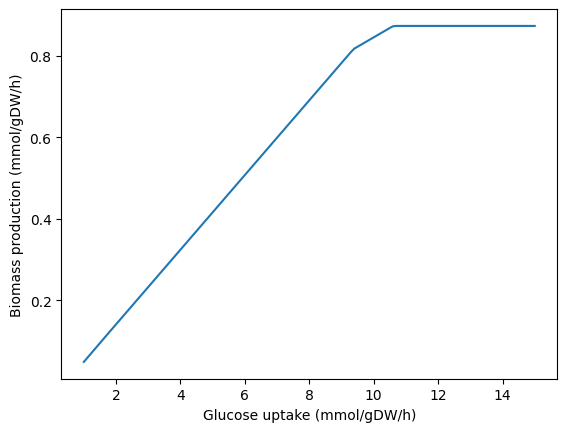

In [7]:
# TASK 4

# a: Plot biomass vs glucose uptake
#grab the reaction once before the loop for efficiency
glc_rxn = model.reactions.get_by_id("EX_glc__D_e") 
uptake_vals = np.arange(1.0, 15.1, 0.1)
biomass_vals = []

for val in uptake_vals:
    glc_rxn.lower_bound = -val
    sol = model.optimize()
    biomass_vals.append(sol.objective_value)

plt.plot(uptake_vals, biomass_vals)
plt.xlabel("Glucose uptake (mmol/gDW/h)")
plt.ylabel("Biomass production (mmol/gDW/h)")
plt.show()

In [ ]:
# c: Identify the active process in the second segment
# set glucose uptake to 10.0
model.reactions.get_by_id("EX_glc__D_e").lower_bound = -10.0 
sol = model.optimize()

# loop through exchanges 
for rxn in model.exchanges:
    flux = sol.fluxes[rxn.id]
    # fluxes greater than 0(secretion)
    if flux > 0.001:
        print(f"{rxn.id}: {flux:.2f}")

EX_ac_e: 1.25
EX_co2_e: 21.53
EX_h_e: 18.21
EX_h2o_e: 27.68


### Conclusion

To sum up, we saw that adding enzyme activity limits to the model shows a much more realistic behavior of the cell. Cell growth depends mainly on two factors: the amount of glucose available outside and the capacity of the enzymes inside.

As we increased the glucose supply, the main respiratory pathways of the cell reached their limit. To process the excess carbon, the cell switched to a fermentation metabolism and started secreting acetate (EX_ac_e).

Finally, the system reached a maximum point where more glucose no longer increases the growth rate. This shows that the internal enzymes are working at their maximum capacity.


